In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [40]:
df=pd.read_csv('sales_dataset_with_issues.csv')

In [41]:
df

,Date,Region,Product Category,Units Sold,Revenue,Salesperson
0,2024-04-29 00:00:00,North,C,137.0,9313.67,Jessica Martinez
1,2024-01-04 00:00:00,North,1,236.0,22419.90,Robert Taylor
2,2024-04-08 00:00:00,WEST,C,145.0,13173.57,David Wilson
3,2024-05-05 00:00:00,North,A,383.0,50299.11,John Smith
4,2024-03-04 00:00:00,North,A,119.0,6089.64,Sarah Johnson
...,...,...,...,...,...,...
75,2024-03-20 00:00:00,South,B,35.0,6979.51,John Smith
76,2024-10-22 00:00:00,North,A,209.0,27793.56,Michael Brown
77,2024-12-12 00:00:00,West,C,340.0,42645.37,John Smith
78,2024-02-21 00:00:00,South,A,384.0,24516.39,Emily Davis


In [42]:
#renaming columns
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')
df.columns.to_list()

['date', 'region', 'product_category', 'units_sold', 'revenue', 'salesperson']

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              77 non-null     object 
 1   region            78 non-null     object 
 2   product_category  79 non-null     object 
 3   units_sold        77 non-null     float64
 4   revenue           79 non-null     float64
 5   salesperson       80 non-null     object 
dtypes: float64(2), object(4)
memory usage: 3.9+ KB


In [44]:
df.describe()

,units_sold,revenue
count,77.000000,79.000000
mean,245.480519,30513.579620
std,158.475020,22526.139477
min,-87.000000,-2892.740000
25%,108.000000,13200.280000
50%,242.000000,24516.390000
75%,383.000000,44654.410000
max,500.000000,88457.780000


- Date column is in object format and long format date
- There are records where the **revenue** and **units_sold** are negative we have to handle that instances

In [45]:
# converting the date column
df['date'].to_list()

['2024-04-29 00:00:00',
 '2024-01-04 00:00:00',
 '2024-04-08 00:00:00',
 '2024-05-05 00:00:00',
 '2024-03-04 00:00:00',
 '2024-04-26 00:00:00',
 '2024-02-14 00:00:00',
 '2024-12-04 00:00:00',
 '2024-01-17 00:00:00',
 '2024-02-17 00:00:00',
 '2024-08-04 00:00:00',
 '2024-05-20 00:00:00',
 '2024-11-21 00:00:00',
 '2024-05-22 00:00:00',
 '2024-11-23 00:00:00',
 '2024-07-12 00:00:00',
 '2024-12-25 00:00:00',
 '2024-10-28 00:00:00',
 nan,
 '2024-06-23 00:00:00',
 '2024-02-10 00:00:00',
 '2024-11-05 00:00:00',
 '2024-01-23 00:00:00',
 '2024-07-13 00:00:00',
 '2024-05-22 00:00:00',
 '2024-10-29 00:00:00',
 '2024-07-02 00:00:00',
 '2024-09-15 00:00:00',
 '2024-02-22 00:00:00',
 '2024-06-21 00:00:00',
 '2024-10-06 00:00:00',
 '2024-08-23 00:00:00',
 '2024-02-05 00:00:00',
 '2024-08-04 00:00:00',
 '2024-08-23 00:00:00',
 '2024-03-12 00:00:00',
 '2024-11-17 00:00:00',
 '2024-04-21 00:00:00',
 '2024-07-05 00:00:00',
 '2024-02-19 00:00:00',
 '2024-12-04 00:00:00',
 '2024-01-16 00:00:00',
 '2024-02-

- There are some null dates, invalid dates and date in %y-%m-%d format

In [46]:
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)

C:\Users\Tanmo\AppData\Local\Temp\ipykernel_7588\3502075259.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)


In [47]:
df.head()

,date,region,product_category,units_sold,revenue,salesperson
0,2024-04-29,North,C,137.0,9313.67,Jessica Martinez
1,2024-01-04,North,1,236.0,22419.90,Robert Taylor
2,2024-04-08,WEST,C,145.0,13173.57,David Wilson
3,2024-05-05,North,A,383.0,50299.11,John Smith
4,2024-03-04,North,A,119.0,6089.64,Sarah Johnson


In [48]:
# messy region input
df['region'].unique()

array(['North', 'WEST', 'South', 'West', 'East', nan, 'Central', 'north',
       'Eastern'], dtype=object)

In [49]:
cleanup_map={'WEST':'West','north':'North','Eastern':'East','N/A':np.nan}
df['region']=df['region'].replace(cleanup_map)

In [50]:
df['region'].unique()

array(['North', 'West', 'South', 'East', nan, 'Central'], dtype=object)

In [51]:
# handling incorrect entry in revenue
incorrect_revenue=df['revenue']<=0
df.loc[incorrect_revenue]

,date,region,product_category,units_sold,revenue,salesperson
30,2024-10-06,South,B,152.0,-2892.74,Michael Brown
54,2024-06-25,South,A,444.0,-2768.64,Emily Davis
64,2024-10-14,West,C,239.0,-1854.81,Jessica Martinez


In [52]:
df['revenue'] = df['revenue'].abs() 

In [53]:
df['units_sold'] = df['units_sold'].abs() 

In [54]:
incorrect_units_sold=df['units_sold']<=0
df.loc[incorrect_units_sold]

,date,region,product_category,units_sold,revenue,salesperson
6,2024-02-14,South,A,0.0,3018.21,Michael Brown
71,2024-03-22,South,B,0.0,41211.44,Emily Davis


In [55]:
# set invalid units_sold to NaN
df.loc[df['units_sold'] <= 0, 'units_sold'] = np.nan

In [56]:
df['product_category'].unique()

array(['C', '1', 'A', 'B', 'AB', 'D', nan, 'a'], dtype=object)

In [57]:
cleanup_map={'1':'A','AB':'A','a':'A','N/A':np.nan}
df['product_category']=df['product_category'].replace(cleanup_map)

In [58]:
df

,date,region,product_category,units_sold,revenue,salesperson
0,2024-04-29,North,C,137.0,9313.67,Jessica Martinez
1,2024-01-04,North,A,236.0,22419.90,Robert Taylor
2,2024-04-08,West,C,145.0,13173.57,David Wilson
3,2024-05-05,North,A,383.0,50299.11,John Smith
4,2024-03-04,North,A,119.0,6089.64,Sarah Johnson
...,...,...,...,...,...,...
75,2024-03-20,South,B,35.0,6979.51,John Smith
76,2024-10-22,North,A,209.0,27793.56,Michael Brown
77,2024-12-12,West,C,340.0,42645.37,John Smith
78,2024-02-21,South,A,384.0,24516.39,Emily Davis


In [59]:
df.isna().sum()

date                5
region              2
product_category    1
units_sold          5
revenue             1
salesperson         0
dtype: int64

In [60]:
df[df['date'].isna()]

,date,region,product_category,units_sold,revenue,salesperson
18,NaT,East,A,256.0,37912.69,David Wilson
44,NaT,East,A,215.0,20404.96,Jessica Martinez
45,NaT,South,C,204.0,13732.12,Sarah Johnson
47,NaT,East,A,84.0,26901.60,John Smith
50,NaT,East,A,411.0,46663.45,David Wilson


In [61]:
df = df.dropna(subset=['date','region','product_category'])

In [62]:
df.isna().sum()

date                0
region              0
product_category    0
units_sold          5
revenue             1
salesperson         0
dtype: int64

In [63]:
df[df['revenue'].isna()]

,date,region,product_category,units_sold,revenue,salesperson
79,2024-08-17,North,A,457.0,NaN,John Smith


In [64]:
avg_price = (df['revenue'] / df['units_sold']).mean()
df.loc[df['revenue'].isna(), 'revenue'] = (
    df.loc[df['revenue'].isna(), 'units_sold'] * avg_price
)

In [65]:
df

,date,region,product_category,units_sold,revenue,salesperson
0,2024-04-29,North,C,137.0,9313.670000,Jessica Martinez
1,2024-01-04,North,A,236.0,22419.900000,Robert Taylor
2,2024-04-08,West,C,145.0,13173.570000,David Wilson
3,2024-05-05,North,A,383.0,50299.110000,John Smith
4,2024-03-04,North,A,119.0,6089.640000,Sarah Johnson
...,...,...,...,...,...,...
75,2024-03-20,South,B,35.0,6979.510000,John Smith
76,2024-10-22,North,A,209.0,27793.560000,Michael Brown
77,2024-12-12,West,C,340.0,42645.370000,John Smith
78,2024-02-21,South,A,384.0,24516.390000,Emily Davis


In [66]:
# handling Duplicates
df.duplicated().sum()

2

In [67]:
df[df.duplicated()]

,date,region,product_category,units_sold,revenue,salesperson
59,2024-02-22,West,A,344.0,47343.56,Michael Brown
67,2024-05-28,West,A,226.0,27861.23,Robert Taylor


- No duplicate

In [68]:
#final df
df.head()

,date,region,product_category,units_sold,revenue,salesperson
0,2024-04-29,North,C,137.0,9313.67,Jessica Martinez
1,2024-01-04,North,A,236.0,22419.90,Robert Taylor
2,2024-04-08,West,C,145.0,13173.57,David Wilson
3,2024-05-05,North,A,383.0,50299.11,John Smith
4,2024-03-04,North,A,119.0,6089.64,Sarah Johnson


In [69]:
# Total Revenue by Region
df.groupby('region')['revenue'].sum()

region
Central     73413.630000
East       412671.790000
North      792364.678988
South      258488.180000
West       684999.170000
Name: revenue, dtype: float64

In [70]:
#Top 3 Salesperson
df.groupby('salesperson')['revenue'].sum().sort_values(ascending=False).head(3)

salesperson
Robert Taylor    465251.840000
John Smith       337281.568988
David Wilson     328244.060000
Name: revenue, dtype: float64

In [74]:
# Best performing product category
df.groupby('product_category').agg({'revenue':'sum','units_sold':'sum'}).sort_values(by='revenue',ascending=False).head(1)

,revenue,units_sold
product_category,,
A,1.035528e+06,8688.0


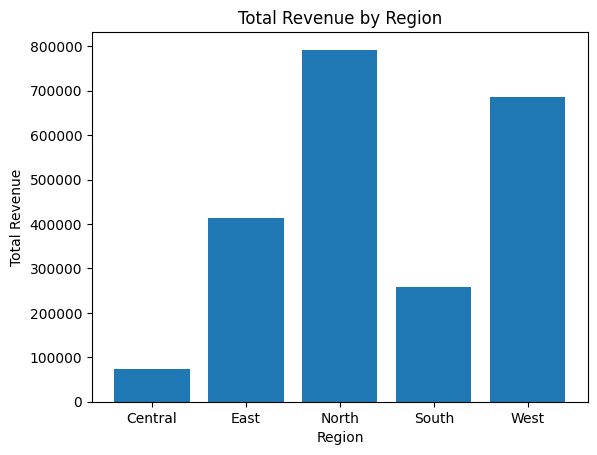

In [75]:
region_revenue = df.groupby('region')['revenue'].sum()

plt.figure()
plt.bar(region_revenue.index, region_revenue.values)
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Region')
plt.show()

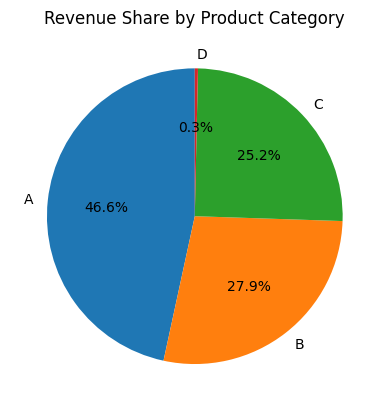

In [76]:
category_revenue = df.groupby('product_category')['revenue'].sum()
plt.figure()
plt.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Revenue Share by Product Category')
plt.show()

In [78]:
df.to_csv('final_sales_data.csv', index=False)

In [77]:
final_df=df
final_df

,date,region,product_category,units_sold,revenue,salesperson
0,2024-04-29,North,C,137.0,9313.670000,Jessica Martinez
1,2024-01-04,North,A,236.0,22419.900000,Robert Taylor
2,2024-04-08,West,C,145.0,13173.570000,David Wilson
3,2024-05-05,North,A,383.0,50299.110000,John Smith
4,2024-03-04,North,A,119.0,6089.640000,Sarah Johnson
...,...,...,...,...,...,...
75,2024-03-20,South,B,35.0,6979.510000,John Smith
76,2024-10-22,North,A,209.0,27793.560000,Michael Brown
77,2024-12-12,West,C,340.0,42645.370000,John Smith
78,2024-02-21,South,A,384.0,24516.390000,Emily Davis


## Business Insights

### 1. Product Category A is the primary revenue driver
Product Category **A contributes ~46.6% of total revenue**, significantly higher than Categories B (27.9%) and C (25.2). This indicates strong customer demand or pricing strength for Category A. The business should prioritize inventory availability, focused marketing, and product innovation in this category to maximize revenue impact.

### 2. North and West regions dominate regional revenue
The **North region generates the highest revenue (~₹792K)**, followed by the **West (~₹685K)**. These regions together contribute the majority of total sales, suggesting strong market penetration and demand concentration. Targeted expansion, localized promotions, and pilot launches would be most effective in these regions.

### 3. Sales performance is concentrated among top performers
**Robert Taylor is the top-performing salesperson (~₹465K in revenue)**, outperforming peers by a significant margin. This indicates an opportunity to analyze and replicate best practices from top performers to improve overall sales productivity and reduce reliance on a small group of high contributors.


## Summary
Product Category A is the largest contributor, accounting for nearly half of total revenue, indicating strong demand and pricing strength. Revenue is geographically concentrated, with the North and West regions generating the highest sales, making them priority markets for growth initiatives. Sales performance is uneven across the team, with a few top performers contributing a significant share of revenue. Replicating successful sales strategies and reallocating resources toward high-performing categories and regions can further improve overall business performance.